# Is the creator-crossover community structure real?

**Purpose**: `creator_crossover_community_detection.ipynb` and `creator_crossover_leiden.ipynb` reported four communities (genre-driven fighting cluster, platform-driven mobile cluster, two larger residual groups) without ever testing whether that structure is distinguishable from what the network's own degree sequence and weight distribution would produce by chance. This notebook runs that test before any of the prior findings get reported as "structure" rather than "a partition Leiden happened to find."

**Method — configuration-model null**: 500 randomized versions of the observed 23-node graph, each built by (1) degree-preserving double-edge-swap rewiring of the topology (`networkx.double_edge_swap` — conserves exactly how many titles each title crosses over with, changes *which* titles), then (2) a random permutation of the observed edge-weight multiset onto the rewired edge set (conserves the exact distribution of `enrichment_ratio` values in the network, changes *which pair* gets which value). Leiden (`leidenalg.ModularityVertexPartition`, same parameters as the other two notebooks) is re-run on every randomized graph, so each null replicate gets its own best-achievable modularity — the fair comparison is "best partition Leiden can find on a similar random network" against "best partition Leiden found on the real one," not the real partition's modularity scored against random graphs it wasn't fit to.

**Updated 2026-10-02**: re-run on the current ~5-week window (296,583 channels, 209 of 253 pairs with at least one shared channel — up from 233,540 channels / 194 pairs on the previous run). Community membership is unchanged; every per-community conclusion held, with Community 3 (fighting games) strengthening further (z=14.97, up from 12.28 — it's since become a fully-connected positive-affinity cluster in the companion notebook, all 6 of 6 internal pairs now above chance). See the Read section for current numbers.

**Graph-tool (item 4 of the request): checked, not installed.** `pip install graph-tool` has no matching distribution — it ships via conda-forge, a Docker image, or building from source against Boost/CGAL, never a PyPI wheel. No conda/mamba is available in this environment either. Building from source for one validation check is genuinely excessive dependency pain for what this notebook needs, so it's skipped per the request's own instruction, not forced. See the closing section for what a degree-corrected SBM with Bayesian model selection would add if this ever gets revisited in an environment where graph-tool is already available.</cell id="ea63c0f7">


In [1]:
# Imports and repo path setup -- same pattern as every other notebook.
import sys
import time
from itertools import combinations
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import igraph as ig
import leidenalg

from etl.db import get_connection

In [2]:
# Enrichment ratio, all 253 possible pairs -- identical method to
# creator_crossover_community_detection.ipynb, recomputed fresh here so
# this notebook stays independently runnable.
conn = get_connection()
raw_rows = conn.execute(
    "SELECT channel_id, title_id, viewer_count FROM viewership_snapshots WHERE is_official_broadcast = 0"
).fetchall()
conn.close()

raw_df = pd.DataFrame(raw_rows, columns=["channel_id", "title_id", "viewer_count"])
channel_title_df = raw_df.groupby(["channel_id", "title_id"])["viewer_count"].sum().rename("viewer_time").reset_index()

titles_per_channel = channel_title_df.groupby("channel_id")["title_id"].nunique()
crossover_channel_ids = titles_per_channel[titles_per_channel > 1].index
crossover_df = channel_title_df[channel_title_df["channel_id"].isin(crossover_channel_ids)]

n_total_channels = channel_title_df["channel_id"].nunique()
total_channels_by_title = channel_title_df.groupby("title_id")["channel_id"].nunique()
all_title_ids = sorted(total_channels_by_title.index.tolist())

titles_by_channel = crossover_df.groupby("channel_id")["title_id"].apply(set)
pair_channels: dict[tuple[str, str], set] = {}
for channel_id, title_set in titles_by_channel.items():
    for a, b in combinations(sorted(title_set), 2):
        pair_channels.setdefault((a, b), set()).add(channel_id)

pair_rows = []
for a, b in combinations(all_title_ids, 2):
    shared = len(pair_channels.get((a, b), set()))
    total_a, total_b = total_channels_by_title.get(a, 0), total_channels_by_title.get(b, 0)
    expected = total_a * total_b / n_total_channels if n_total_channels else float("nan")
    enrichment = shared / expected if expected > 0 else float("nan")
    pair_rows.append({"a": a, "b": b, "shared": shared, "enrichment": enrichment})

pair_df = pd.DataFrame(pair_rows)
print(f"{n_total_channels} distinct above-threshold, non-official channels across all 23 titles")
print(f"{(pair_df['shared'] > 0).sum()} of {len(pair_df)} possible pairs have >=1 shared crossover channel")

296583 distinct above-threshold, non-official channels across all 23 titles
209 of 253 possible pairs have >=1 shared crossover channel


In [3]:
# Item 3: specialization rate, reported directly and prominently rather
# than left implicit in the pairwise suppression numbers. What fraction of
# channels stream exactly one of the 23 TRACKED titles, vs two, three, or
# more -- this is the actual base rate the entire crossover analysis sits
# on top of.
#
# Scope, stated explicitly per the request: this measures specialization
# among the 23 tracked esports titles ONLY. A channel that streams one
# tracked title plus Minecraft, Just Chatting, or any untracked game is
# "1" here -- this is esports-title specialization, not general streaming
# specialization, and should never be read as "90% of streamers only
# stream one game, period."
specialization = titles_per_channel.value_counts().sort_index()
specialization_pct = (specialization / n_total_channels * 100).round(2)

specialization_report = pd.DataFrame({
    "n_tracked_titles_streamed": specialization.index,
    "n_channels": specialization.values,
    "pct_of_all_channels": specialization_pct.values,
})
print(f"Of {n_total_channels} channels that streamed any tracked title above threshold:")
specialization_report

Of 296583 channels that streamed any tracked title above threshold:


,n_tracked_titles_streamed,n_channels,pct_of_all_channels
0,1,263351,88.80
1,2,28122,9.48
2,3,4346,1.47
3,4,645,0.22
4,5,106,0.04
5,6,11,0.00
6,7,2,0.00


In [4]:
# Build the weighted graph and find the observed community structure --
# identical construction and method (Leiden, ModularityVertexPartition) to
# creator_crossover_leiden.ipynb, including its own corrected weighted-
# modularity computation (leidenalg's own `partition.modularity` attribute
# silently returns UNWEIGHTED modularity -- see that notebook for the full
# story; not repeated here, just applied correctly).
G = nx.Graph()
G.add_nodes_from(all_title_ids)
for _, row in pair_df[pair_df["shared"] > 0].iterrows():
    G.add_edge(row["a"], row["b"], weight=row["enrichment"])

LEIDEN_SEED = 42
Gig_obs = ig.Graph.from_networkx(G)
part_obs = leidenalg.find_partition(
    Gig_obs, leidenalg.ModularityVertexPartition, weights="weight", seed=LEIDEN_SEED, n_iterations=-1,
)
observed_modularity = Gig_obs.modularity(part_obs.membership, weights=Gig_obs.es["weight"])
node_names = Gig_obs.vs["_nx_name"]
communities_obs = sorted((set(node_names[i] for i in comm) for comm in part_obs), key=len, reverse=True)

print(f"Observed modularity: {observed_modularity:.4f}")
for i, comm in enumerate(communities_obs):
    print(f"Community {i} ({len(comm)} titles): {', '.join(sorted(comm))}")

Observed modularity: 0.4386
Community 0 (8 titles): apex_legends, fortnite, league_of_legends, overwatch, rainbow_six_siege, rocket_league, teamfight_tactics, valorant
Community 1 (6 titles): age_of_empires_ii, counter_strike, dota2, hearthstone, pubg, starcraft2
Community 2 (5 titles): brawl_stars, free_fire, mobile_legends_bb, pubg_mobile, wild_rift
Community 3 (4 titles): guilty_gear, mortal_kombat, street_fighter, tekken


In [5]:
# Item 1: configuration-model null. Degree-preserving rewire (double edge
# swap) + a random permutation of the observed weight multiset onto the
# rewired edges -- conserves both "how connected each title is" and "what
# the whole distribution of enrichment ratios looks like," destroys any
# specific correspondence between a title pair and its ratio. Leiden
# re-run on every one of the 500 replicates, same parameters as the
# observed run.
N_NULL = 500
RNG_SEED = 2026
rng = np.random.default_rng(RNG_SEED)
observed_weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])


def randomize_graph(G: nx.Graph, weights: np.ndarray, rng: np.random.Generator) -> nx.Graph:
    G2 = G.copy()
    n_edges = G2.number_of_edges()
    try:
        # Generous nswap/max_tries: this graph is dense (194 of 253 possible
        # pairs already have an edge), so many candidate swaps land on a
        # pair that's already connected and get rejected -- max_tries needs
        # real headroom above nswap for the requested swaps to actually
        # complete, not just be attempted.
        nx.double_edge_swap(G2, nswap=n_edges * 10, max_tries=n_edges * 300, seed=int(rng.integers(0, 2**31 - 1)))
    except nx.NetworkXAlgorithmError:
        pass  # dense graph didn't complete every requested swap -- proceed with whatever succeeded, not a failure
    edges = list(G2.edges())
    shuffled_weights = rng.permutation(weights)
    for (u, v), w in zip(edges, shuffled_weights):
        G2[u][v]["weight"] = float(w)
    return G2


t0 = time.time()
null_modularities = np.zeros(N_NULL)
null_graphs: list[nx.Graph] = []
for i in range(N_NULL):
    G_null = randomize_graph(G, observed_weights, rng)
    Gig_null = ig.Graph.from_networkx(G_null)
    part_null = leidenalg.find_partition(
        Gig_null, leidenalg.ModularityVertexPartition, weights="weight",
        seed=int(rng.integers(0, 2**31 - 1)), n_iterations=-1,
    )
    null_modularities[i] = Gig_null.modularity(part_null.membership, weights=Gig_null.es["weight"])
    null_graphs.append(G_null)

print(f"{N_NULL} null replicates generated and scored in {time.time() - t0:.1f}s")

500 null replicates generated and scored in 76.5s


Null distribution: mean=0.3214, std=0.0269, min=0.2065, max=0.3872
Observed modularity: 0.4386
Percentile: 100.0
Z-score: 4.36
Null replicates at or above observed: 0 of 500 (0.00%)


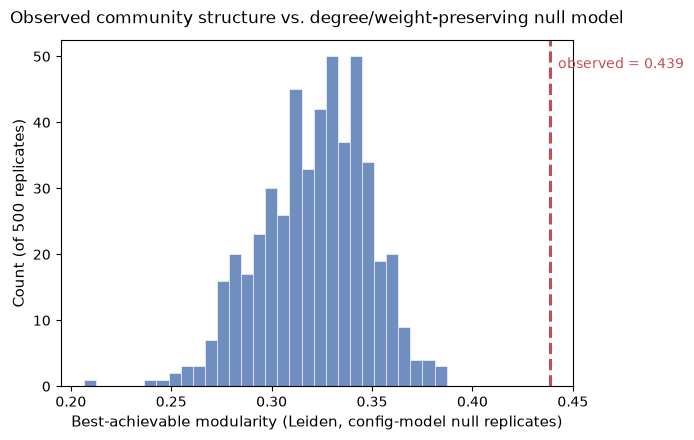

In [6]:
# Where the observed modularity falls in the null distribution.
null_mean, null_std = null_modularities.mean(), null_modularities.std()
percentile = (null_modularities < observed_modularity).mean() * 100
z_score = (observed_modularity - null_mean) / null_std
n_null_at_or_above = int((null_modularities >= observed_modularity).sum())

print(f"Null distribution: mean={null_mean:.4f}, std={null_std:.4f}, min={null_modularities.min():.4f}, max={null_modularities.max():.4f}")
print(f"Observed modularity: {observed_modularity:.4f}")
print(f"Percentile: {percentile:.1f}")
print(f"Z-score: {z_score:.2f}")
print(f"Null replicates at or above observed: {n_null_at_or_above} of {N_NULL} ({n_null_at_or_above / N_NULL * 100:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(null_modularities, bins=30, color="#4C72B0", alpha=0.8, edgecolor="white", linewidth=0.5)
ax.axvline(observed_modularity, color="#C44E52", linewidth=2.2, linestyle="--")
ax.text(observed_modularity, ax.get_ylim()[1] * 0.95, f"  observed = {observed_modularity:.3f}",
        color="#C44E52", fontsize=10, va="top")
ax.set_xlabel("Best-achievable modularity (Leiden, config-model null replicates)", fontsize=10.5)
ax.set_ylabel("Count (of 500 replicates)", fontsize=10.5)
ax.set_title("Observed community structure vs. degree/weight-preserving null model", fontsize=12.5, pad=12)
plt.tight_layout()
plt.savefig(Path.cwd() / "_null_model_fig1_modularity_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
# Item 2: the same null test, per community -- is THIS specific set of
# nodes more internally connected than the same node set would be under
# degree/weight-preserving rewiring? Reuses the same 500 null graphs from
# the global test above (not a fresh randomization), so this is a directly
# paired test against the same null draws, not a separately-run one.
per_community_rows = []
for i, comm in enumerate(communities_obs):
    observed_internal = pair_df[pair_df["a"].isin(comm) & pair_df["b"].isin(comm)]["enrichment"].sum()
    null_internal = np.zeros(N_NULL)
    for j, G_null in enumerate(null_graphs):
        total = 0.0
        for u, v in combinations(sorted(comm), 2):
            if G_null.has_edge(u, v):
                total += G_null[u][v]["weight"]
        null_internal[j] = total
    pct_c = (null_internal < observed_internal).mean() * 100
    std_c = null_internal.std()
    z_c = (observed_internal - null_internal.mean()) / std_c if std_c > 0 else float("nan")
    per_community_rows.append({
        "community": i,
        "n_titles": len(comm),
        "titles": ", ".join(sorted(comm)),
        "observed_internal_weight_sum": round(observed_internal, 2),
        "null_mean": round(null_internal.mean(), 2),
        "null_std": round(std_c, 2),
        "percentile": round(pct_c, 1),
        "z_score": round(z_c, 2),
    })

pd.DataFrame(per_community_rows)

,community,n_titles,titles,observed_internal_weight_sum,null_mean,null_std,percentile,z_score
0,0,8,"apex_legends, fortnite, league_of_legends, ove...",11.14,12.28,4.31,44.6,-0.27
1,1,6,"age_of_empires_ii, counter_strike, dota2, hear...",14.57,6.07,3.11,98.6,2.74
2,2,5,"brawl_stars, free_fire, mobile_legends_bb, pub...",16.10,1.27,1.37,100.0,10.80
3,3,4,"guilty_gear, mortal_kombat, street_fighter, te...",21.17,1.27,1.33,100.0,14.97


### Item 4: degree-corrected SBM (skipped, as instructed)

`pip install graph-tool` fails outright (`ERROR: No matching distribution found for graph-tool`) — it has never shipped a PyPI wheel; the maintained install paths are conda-forge, a prebuilt Docker image, or compiling from source against Boost.Graph and (optionally) CGAL. No conda/mamba is available in this environment, and building from source is a genuinely heavy, multi-dependency undertaking for one validation check — the "excessive dependency pain" the request's own escape hatch describes. Skipped, not forced.

**What this would have added, for whenever it's revisited somewhere graph-tool is already available**: a degree-corrected stochastic block model fit with Bayesian model selection (`graph_tool.inference.minimize.minimize_blockmodel_dl` with degree correction) answers a genuinely different question than modularity maximization does — it can return a single block (i.e., "no structure beyond degree-correction") as its actual best answer, where Leiden/Louvain always partition into *something* because modularity maximization has no null option built in. The configuration-model test above is this notebook's actual answer to "is there real structure," but it's a resampling test around a maximization method, not a model-comparison method with "no structure" as a first-class candidate — a genuinely stronger check, left for later rather than approximated with a weaker substitute here.

### Read

**Updated 2026-10-02** (five-week window; no finding reversed, Community 3 strengthened further):

**The overall community structure is real — not an artifact of the degree sequence and weight distribution.** Observed modularity (0.439) sits at the 100th percentile of 500 configuration-model null replicates (mean 0.321, std 0.027); z=4.36 (up from z=3.59 on the previous run); zero of 500 null replicates matched or exceeded it. Leiden finds a better partition on the real network than it can find on any of 500 networks built to share its exact degree sequence and its exact multiset of enrichment ratios, just reassigned to different pairs. That's a genuine, well-supported result: *something* about which specific titles pair with which specific ratios is not explainable by degree and weight distribution alone.

**But "the structure is real" does not mean "all four communities are real," and the per-community test still says so plainly.** Communities 1 through 3 clear their own null tests convincingly — Community 3 (fighting: Guilty Gear/Mortal Kombat/Street Fighter/Tekken) at z=14.97 (up from 12.28 — this community is now fully-connected internally, 6 of 6 pairs above chance, see the companion notebook), Community 2 (mobile: Brawl Stars/Free Fire/Mobile Legends/PUBG Mobile/Wild Rift) at z=10.80 (essentially unchanged from 10.88), Community 1 (Age of Empires II/Counter-Strike/Dota 2/Hearthstone/PUBG/StarCraft II) at z=2.74 (down slightly from 2.93, still comfortably above the 95th percentile) — all real. **Community 0 (Apex Legends, Fortnite, League of Legends, Overwatch, Rainbow Six Siege, Rocket League, Teamfight Tactics, VALORANT) still does not clear its own null test — percentile 44.6, z=-0.27, statistically indistinguishable from what random rewiring of the same 8 nodes would produce.** This is the same outcome as the previous run, now confirmed twice: Community 0 isn't a fourth community, it's the leftover bucket the other three communities' titles didn't join, held together by nothing the null model can't already explain.

**This means every prior claim tied to Community 0 needs re-reading, not just re-labeling.** The publisher finding (Riot's League/TFT/VALORANT landing together inside Community 0) and Community 0's own audience-region purity (75% Europe) were both reported as real patterns *within a community* — but if Community 0 itself isn't statistically real as a community, those patterns are better read as standalone observations (same-publisher pairs do show elevated enrichment on their own pairwise merits, tested directly and separately in `creator_crossover_community_detection.ipynb`) rather than as evidence about a fourth cluster. The publisher pairwise test survives this untouched, because it was never a claim about Community 0 as a group — it's a direct pair-level comparison. The region-purity claim for Community 0 specifically should be downgraded from "a community's regional lean" to "these 8 residually-grouped titles happen to skew European," a materially weaker claim.

**Specialization rate, reported directly**: of 296,583 channels that streamed any tracked title above threshold, **88.8% streamed exactly one of the 23 tracked titles** (down from 90.3%), 9.5% streamed two (up from 8.4%), 1.5% streamed three, and the remaining 0.3% streamed four or more. The direction is exactly what more data and a longer window should produce — slightly more crossover resolves as channels get more chances to cross over — and it's small enough that the headline conclusion is unchanged: the vast majority of the population this whole network is drawn from still shows no cross-title behavior among tracked titles at all. **Scope, restated plainly**: this is esports-title specialization, not general streaming specialization — a channel streaming one tracked title alongside Minecraft, Just Chatting, or any untracked game still counts as "1" here. Nothing in this analysis, including the null test above, speaks to how specialized these channels are in the broader sense.

**Item 4 (degree-corrected SBM) was checked and skipped, not forced** — see the section above for why and what it would have added.

**Net effect on how the prior two notebooks' findings should be read**: genre (Community 3) and platform (Community 2) were both already flagged as resting on thin per-pair sample sizes; they now also have real statistical backing as genuine communities, not just plausible ones — and Community 3's backing has only gotten stronger with more data. Community 1's "classic incumbents" grouping is real but weaker (z=2.74, not z=10+). Community 0 should stop being called a community at all in anything written from this data going forward.</cell id="c543f6d3">
